<a href="https://colab.research.google.com/github/TenofJiwon/DerivativeSecurities/blob/main/MonteCarlo_Simulation_Cholesky_Decomposition_Correlated_Asset_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
n=10000; r=0.03; vol=0.30

prd1=np.busday_count('2025-12-01','2026-05-28')
prd2=np.busday_count('2025-12-01','2026-11-27')
prd3=np.busday_count('2025-12-01','2027-05-28')
prd4=np.busday_count('2025-12-01','2027-11-26')
prd5=np.busday_count('2025-12-01','2028-05-26')
prd6=np.busday_count('2025-12-01','2028-11-28')
check_day=np.array([prd1,prd2,prd3,prd4,prd5,prd6])

oneyear=252; tot_date=prd6; dt=1/oneyear

S=np.zeros([tot_date+1,1]); S[0]=100.00

strike_price=np.array([0.95,0.90,0.90,0.85,0.85,0.75])*S[0]
repay_n=len(strike_price)

coupon_rate=np.array([0.0428,0.0856,0.1284,0.1712,0.2140,0.2568])
payment=np.zeros([repay_n,1])
facevalue=10000

tot_payoff=np.zeros([repay_n,1])
payoff=np.zeros([repay_n,1])
discount_payoff=np.zeros([repay_n,1])

kib=0.55*S[0]; dummy=0.2568

for j in range(repay_n):
  payment[j]=facevalue*(1+coupon_rate[j])
for i in range(n):
  e=np.random.normal(0,1,size=[tot_date,1])

  for j in range(tot_date):
    S[j+1]=S[j]*np.exp((r-0.5*vol**2)*dt+vol*np.sqrt(dt)*e[j])

  S_checkday=S[check_day]
  payoff = np.zeros([repay_n,1]); repay_event=0

  for j in range(repay_n):
    if S_checkday[j] >= strike_price[j]:
      payoff[j]=payment[j]
      repay_event=1
      break
    if repay_event==0:
      if min(S)>kib:
        payoff[-1]=facevalue*(1+dummy)
      else:
        payoff[-1]=facevalue*(S[-1]/S[0])
    tot_payoff=tot_payoff+payoff

mean_payoff=tot_payoff/n

for j in range(repay_n):
  discount_payoff[j]=mean_payoff[j]*np.exp(-r*check_day[j]/oneyear)

price=np.sum(discount_payoff)
print(price)

10081.787279529433


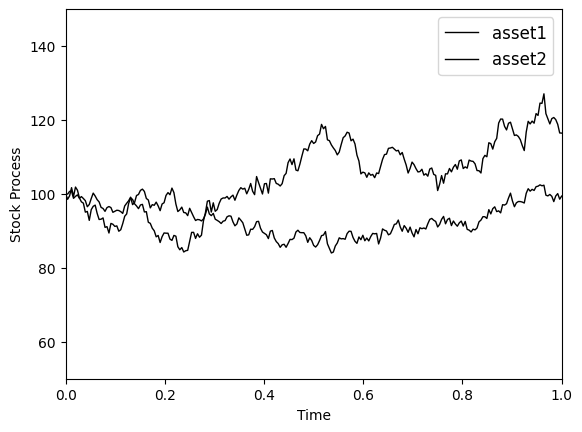

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_vol=0.25; y_vol=0.2
r=0.03; N=252; T=1; dt=T/N
rho=0.3

S1=np.zeros([N+1,1])
S2=np.zeros([N+1,1])
S1[0]=100; S2[0]=100

corr_matrix=np.array([[1,rho],[rho,1]])
cholesky=np.linalg.cholesky(corr_matrix)

e0=np.random.normal(0,1,size=[N,2])
e0=np.transpose(e0)
e=np.matmul(cholesky,e0)

for i in range(N):
  S1[i+1]=S1[i]*np.exp((r-0.5*x_vol**2)*dt+x_vol*e[0,i]*np.sqrt(dt))
  S2[i+1]=S2[i]*np.exp((r-0.5*y_vol**2)*dt+y_vol*e[1,i]*np.sqrt(dt))

t=np.linspace(0,T,N+1)
plt.plot(t,S1[:],'k-',label='asset1',linewidth=1,markersize=3.5)
plt.plot(t,S2[:],'k-',label='asset2',linewidth=1,markersize=3.5)

plt.legend()
plt.xlim(0,1)
plt.ylim(50,150)
plt.xlabel('Time')
plt.ylabel('Stock Process')
plt.legend(prop={'size':12})
plt.show()

In [ ]:
import numpy as np
n=10000; r=0.03; rho=0.380;
x_vol=0.606; y_vol=0.530

prd1=np.busday_count('2025-12-01','2026-05-28')
prd2=np.busday_count('2025-12-01','2026-11-27')
prd3=np.busday_count('2025-12-01','2027-05-28')
prd4=np.busday_count('2025-12-01','2027-11-26')
prd5=np.busday_count('2025-12-01','2028-05-26')
prd6=np.busday_count('2025-12-01','2028-11-28')
check_day=np.array([prd1,prd2,prd3,prd4,prd5,prd6])

oneyear=252; tot_date=prd6; dt=1/oneyear

S1=np.zeros([tot_date+1,1]); S2=np.zeros([tot_date+1,1])
S1[0]=100; S2[0]=100
ini_S1=S1[0]; ini_S2=S2[0]
strike_price=[0.90,0.85,0.80, 0.80,0.75,0.70]
repay_n=len(strike_price)

coupon_rate=np.array([0.086,0.172,0.258,0.344,0.430,0.516])
kib=0.30;dummy=0.516
facevalue=10000
payment=np.zeros([repay_n,1])

for j in range(repay_n):
  payment[j]=facevalue*(1+coupon_rate[j])

corr=np.array([[1,rho],[rho,1]])
l=np.linalg.cholesky(corr)


tot_payoff=np.zeros([repay_n,1])
payoff=np.zeros([repay_n,1])
discount_payoff=np.zeros([repay_n,1])

for i in range(n):
  e0=np.random.normal(0,1,size=[tot_date,2])
  e0=np.transpose(e0)
  e=np.matmul(l,e0)

  for j in range(tot_date):
     S1[j+1]=S1[j]*np.exp((r-0.5*x_vol**2)*dt+x_vol*np.sqrt(dt)*e[0,j])
     S2[j+1]=S2[j]*np.exp((r-0.5*y_vol**2)*dt+y_vol*np.sqrt(dt)*e[0,j])
  R1=S1/ini_S1; R2=S2/ini_S2
  WP=np.minimum(R1,R2)
  WP_checkday=WP[check_day]
  payoff=np.zeros([repay_n,1]); repay_event=0

  for j in range(repay_n):
    if WP_checkday[j] >= strike_price[j]:
      payoff[j]=payment[j]
      repay_event=1
      break
    if repay_event==0:
      if min(WP)>kib:
        payoff[-1]=facevalue*(1+dummy)
      else:
        payoff[-1]=facevalue*WP[-1]
    tot_payoff=tot_payoff+payoff
mean_payoff=tot_payoff/n

for j in range(repay_n):
  discount_payoff[j]=mean_payoff[j]*np.exp(-r*check_day[j]/oneyear)

price=np.sum(discount_payoff)
print(price)

10494.770826247419


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data=pd.read_excel('/content/stock_data.xlsx')
data=data.set_index('Date')
start='20210101'
end='20251114'
data=data.loc[start:end]

print(data)

price1=data['005930'].dropna()
price2=data['NVDA'].dropna()

ret1 = price1.pct_change()
ret2 = price2.pct_change()

returns_s1=pd.DataFrame(returns_s1)
returns_s2=pd.DataFrame(returns_s2)
returns=pd.merge(returns_s1,returns_s2,left_index=True,right_index=True,how='left')
rho=np.array(returns.corr())
print(rho[0][1])
print(rho)
https://www.samsungpop.com/?MENU_CODE=M1400066332648